# Projet E-Commerce


In [1]:
# import Bibliotheques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# charger le fichier CSV 
df_customer = pd.read_csv('customers.csv')
df_product = pd.read_csv('products.csv')
df_order = pd.read_csv('orders.csv')
df_transaction = pd.read_csv('transactions.csv')


In [3]:
# lire les 5 premieres lignes du fichier customers
df_customer.head()

,customer_id,customer_name,region
0,1,Alice,North
1,2,Bob,South
2,3,Charlie,East
3,4,David,West
4,5,Eve,North


In [4]:
# lire les 5 premieres lignes du fichier products
df_product.head()

,product_id,product_name,category,price
0,101,Laptop,Electronics,1000
1,102,Smartphone,Electronics,500
2,103,Tablet,Electronics,300
3,104,Headphones,Accessories,100
4,105,Monitor,Electronics,200


In [5]:
# lire les 5 premieres lignes du fichier transactions
df_transaction.head()

,transaction_id,order_id,payment_method,payment_status
0,5001,1001,Card,Completed
1,5002,1002,PayPal,Completed
2,5003,1003,Card,Completed
3,5004,1004,Transfer,Completed
4,5005,1005,Card,Completed


In [6]:
# lire les 5 premieres lignes du fichier orders
df_order.head()

,order_id,customer_id,product_id,quantity,order_date
0,1001,1,101,1,2023-01-01
1,1002,2,102,2,2023-01-16
2,1003,3,103,1,2023-01-31
3,1004,4,104,3,2023-02-15
4,1005,5,105,1,2023-03-02


# Fusion des Tables

In [7]:
df=pd.merge(df_order, df_customer, on='customer_id', how='left')\
    .merge(df_transaction, on='order_id', how='left')\
    .merge(df_product, on='product_id', how='left')

In [8]:
df.shape, df.columns

((20, 13),
 Index(['order_id', 'customer_id', 'product_id', 'quantity', 'order_date',
        'customer_name', 'region', 'transaction_id', 'payment_method',
        'payment_status', 'product_name', 'category', 'price'],
       dtype='object'))

In [10]:
df.head()

,order_id,customer_id,product_id,quantity,order_date,customer_name,region,transaction_id,payment_method,payment_status,product_name,category,price
0,1001,1,101,1,2023-01-01,Alice,North,5001,Card,Completed,Laptop,Electronics,1000
1,1002,2,102,2,2023-01-16,Bob,South,5002,PayPal,Completed,Smartphone,Electronics,500
2,1003,3,103,1,2023-01-31,Charlie,East,5003,Card,Completed,Tablet,Electronics,300
3,1004,4,104,3,2023-02-15,David,West,5004,Transfer,Completed,Headphones,Accessories,100
4,1005,5,105,1,2023-03-02,Eve,North,5005,Card,Completed,Monitor,Electronics,200


# Nettoyage des données

In [11]:
df.dropna(subset=['order_id', 'customer_id', 'product_id'], inplace=True)
df.drop_duplicates(inplace=True)

In [12]:
df=df[df["price"]>0]
df["order_date"]=pd.to_datetime(df["order_date"])

# Feature Engenieuring

In [13]:
df["month"]=df["order_date"].dt.to_period('M')
df["year"]=df["order_date"].dt.year
df["day"]=df["order_date"].dt.day
df["day_of_week"]=df["order_date"].dt.dayofweek

In [14]:
df["revenue"]=df["quantity"]*df["price"]

In [16]:
df.head()

,order_id,customer_id,product_id,quantity,order_date,customer_name,region,transaction_id,payment_method,payment_status,product_name,category,price,month,year,day,day_of_week,revenue
0,1001,1,101,1,2023-01-01,Alice,North,5001,Card,Completed,Laptop,Electronics,1000,2023-01,2023,1,6,1000
1,1002,2,102,2,2023-01-16,Bob,South,5002,PayPal,Completed,Smartphone,Electronics,500,2023-01,2023,16,0,1000
2,1003,3,103,1,2023-01-31,Charlie,East,5003,Card,Completed,Tablet,Electronics,300,2023-01,2023,31,1,300
3,1004,4,104,3,2023-02-15,David,West,5004,Transfer,Completed,Headphones,Accessories,100,2023-02,2023,15,2,300
4,1005,5,105,1,2023-03-02,Eve,North,5005,Card,Completed,Monitor,Electronics,200,2023-03,2023,2,3,200


# Statistique descriptives

In [17]:
df[["revenue", "quantity", "price"]].describe().T

,count,mean,std,min,25%,50%,75%,max
revenue,20.0,635.0,521.410032,100.0,200.0,350.0,1000.0,2000.0
quantity,20.0,1.5,0.688247,1.0,1.0,1.0,2.0,3.0
price,20.0,455.0,350.150344,100.0,200.0,300.0,625.0,1000.0


# Top produits

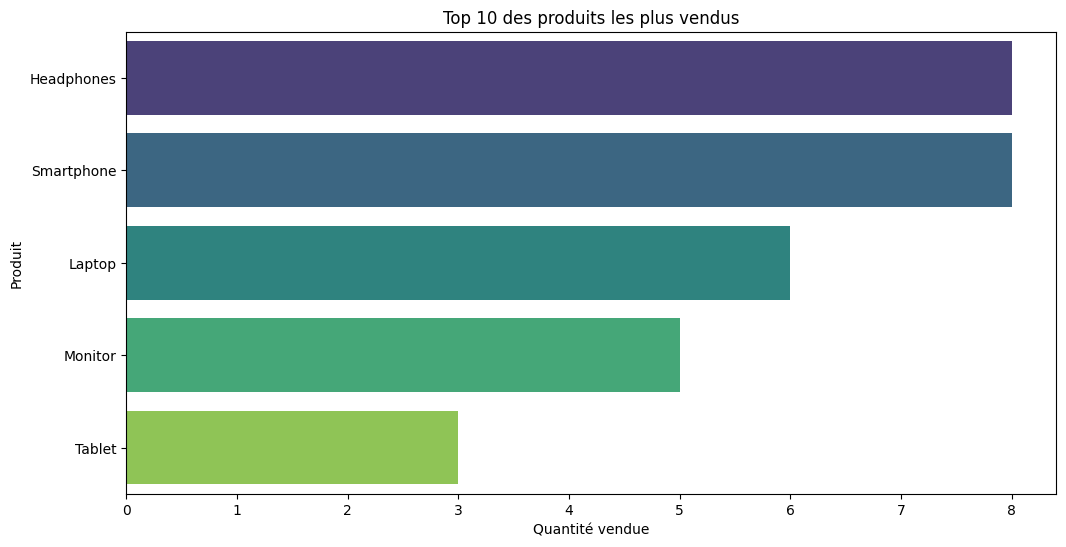

In [18]:
# Les produits les plus vendus
top_products = df.groupby('product_name')['quantity'].sum().reset_index()
top_products = top_products.sort_values(by='quantity', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='quantity', y='product_name', data=top_products, palette='viridis')
plt.title('Top 10 des produits les plus vendus')
plt.xlabel('Quantité vendue')
plt.ylabel('Produit')
plt.show()

# revenue par mois

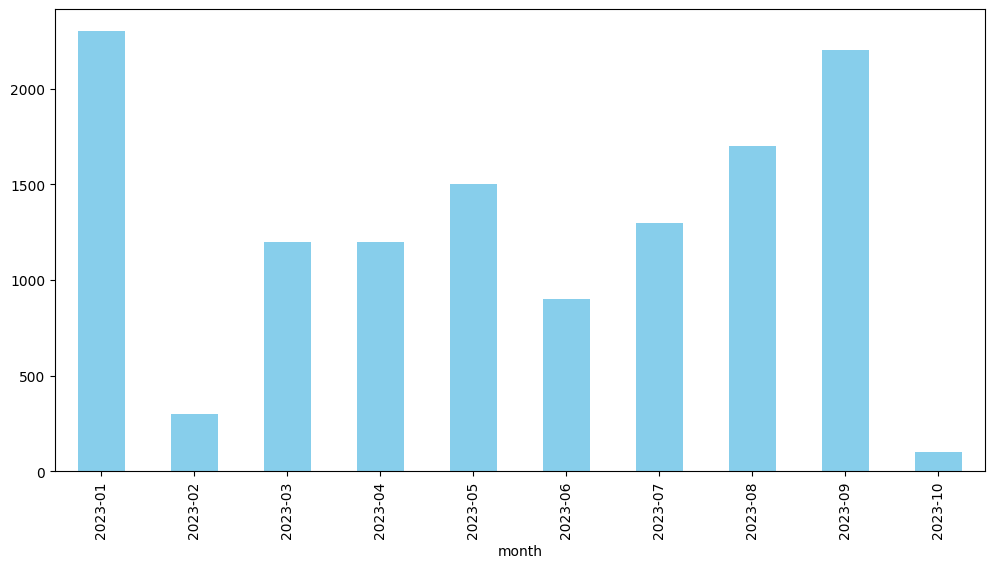

In [20]:
# revenue par mois
monthly_revenue = df.groupby('month')['revenue'].sum().plot(kind='bar', figsize=(12, 6), color='skyblue')

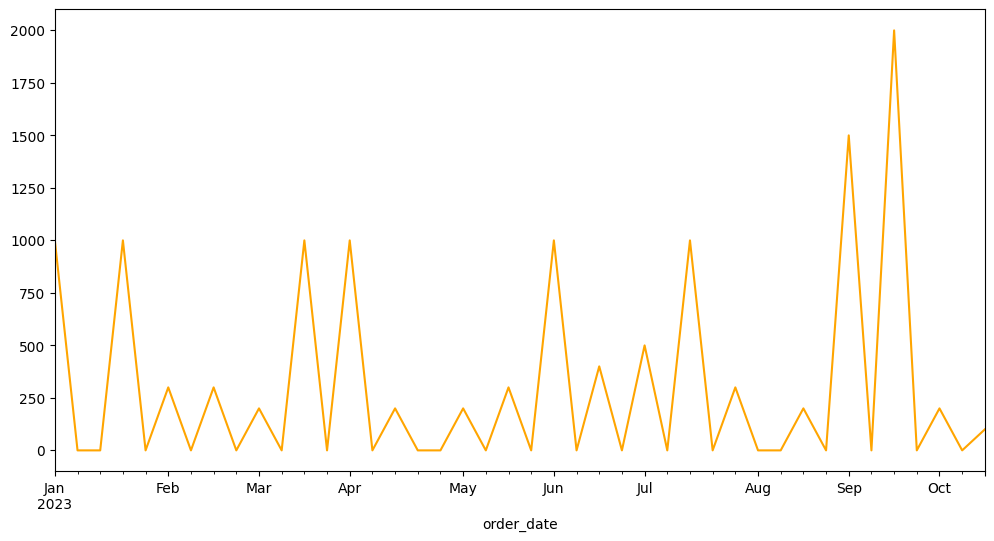

In [22]:
# revenue par week
weekly_revenue = df.groupby('order_date')['revenue'].sum().resample('W').sum().plot(kind='line', figsize=(12, 6), color='orange')



# Heatmap des ventes

c:\Users\wilfr\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


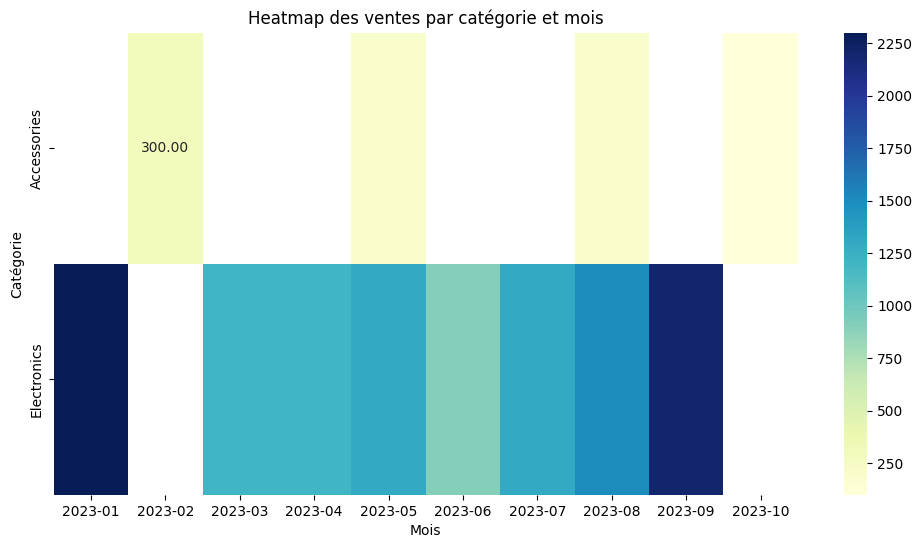

In [23]:
pivot=df.pivot_table(index='category', columns='month', values='revenue', aggfunc='sum')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Heatmap des ventes par catégorie et mois')
plt.xlabel('Mois')
plt.ylabel('Catégorie')
plt.show()

# Preparation pour ML

In [24]:
# preparation des données pour le machine learning
features= df[['quantity', 'price']]
target = df['revenue']


In [27]:
# regression lineare
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



In [28]:
# Evaluation des performances du modèle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Absolute Error: 254.98882503192857
Mean Squared Error: 105277.01702974619
R^2 Score: 0.7416514919515431
